# 1D-CNN 피부층 깊이 예측 — 학습 노트북

**입력**: 2050샘플 ADC 신호 (18.5~39.0μs) → 정규화 [-1, +1]  
**출력**: `[dermis_mm, fascia_mm]`  
**평가**: Leave-One-Patient-Out Cross-Validation  
**목표**: 진피 < 0.30mm, 근막 < 0.30mm MAE

---
**사용법**
1. `[설정] 하이퍼파라미터` 셀에서 파라미터 조정 후 전체 실행 (`Kernel → Restart & Run All`)
2. 또는 셀 하나씩 실행하며 결과 확인
3. `[그리드 서치]` 섹션은 독립적으로 실행 가능

## 0. 환경 설정

In [1]:
import re, json, pickle, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from IPython.display import clear_output, display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.notebook import tqdm
    print("tqdm.notebook 사용")
except ImportError:
    from tqdm import tqdm

# ── 한글 폰트 설정 ────────────────────────────────────────────
# Noto Sans CJK (한/중/일 통합) 폰트 경로 직접 등록
_ko_candidates = [f.fname for f in fm.fontManager.ttflist if 'Noto Sans CJK' in f.name]
if _ko_candidates:
    _ko_path = _ko_candidates[0]
    fm.fontManager.addfont(_ko_path)
    _ko_name = fm.FontProperties(fname=_ko_path).get_name()
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [_ko_name, 'DejaVu Sans']
    print(f"한글 폰트 적용: {_ko_name}  ({_ko_path})")
else:
    print("한글 폰트 없음")
plt.rcParams['axes.unicode_minus'] = False

ROOT       = Path(".").resolve()
USDATA     = ROOT / "usdata" / "data"
RESULT_DIR = ROOT / "results"
RESULT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRIM_START, TRIM_COUNT = 1850, 2050
SOUND_SPEED = 1540.0

FILENAME_RE = re.compile(
    r'^(?P<name>.+)_(?P<date>\d{8})_(?P<time>\d{6})_'
    r'\((?P<pos_num>\d+)\)(?P<position>.+?)_(?P<gender>[MF])\.csv$'
)

print(f"Device : {DEVICE}")
print(f"USDATA : {USDATA}")
print(f"Device : {DEVICE}")
print(f"USDATA : {USDATA}")
print(f"Results: {RESULT_DIR}")
print(f"TRIM   : start={TRIM_START}  count={TRIM_COUNT}  ({TRIM_START*0.01:.1f}~{(TRIM_START+TRIM_COUNT)*0.01:.1f}μs)")

tqdm.notebook 사용
한글 폰트 적용: Noto Sans CJK JP  (/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc)
Device : cpu
USDATA : /home/dmjang/work/ultrasound_analysis/usdata/data
Device : cpu
USDATA : /home/dmjang/work/ultrasound_analysis/usdata/data
Results: /home/dmjang/work/ultrasound_analysis/results
TRIM   : start=1850  count=2050  (18.5~39.0μs)


## 1. 데이터 로드

In [2]:
def load_adc(path):
    adc = []
    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:
                v = int(line)
                if 0 <= v <= 255: adc.append(v)
            except ValueError: pass
    adc = np.array(adc, dtype=np.float32)
    if len(adc) > TRIM_COUNT:
        end = TRIM_START + TRIM_COUNT
        adc = adc[TRIM_START:end] if len(adc) >= end else adc[TRIM_START:]
    if len(adc) < TRIM_COUNT:
        adc = np.pad(adc, (0, TRIM_COUNT - len(adc)))
    return adc[:TRIM_COUNT]


def load_label(csv_path):
    json_path = csv_path.with_name(csv_path.stem + "_positions.json")
    if not json_path.exists(): return None
    with open(json_path, encoding="utf-8") as f:
        data = json.load(f)
    dermis_mm = fascia_mm = None
    for pos in data.get("positions", []):
        name = pos.get("position_name", "")
        mm   = pos.get("thickness_mm")
        if name in ("피하지방시작", "Dermis") and mm is not None:
            dermis_mm = float(mm)
        elif name == "Fascia" and mm is not None:
            fascia_mm = float(mm)
    if dermis_mm is None or fascia_mm is None: return None
    return dermis_mm, fascia_mm


def build_dataset():
    rows = []
    for csv_path in sorted(USDATA.rglob("*.csv")):
        if "_positions" in csv_path.name: continue
        m = FILENAME_RE.match(csv_path.name)
        if not m: continue
        label = load_label(csv_path)
        if label is None: continue
        adc = load_adc(csv_path)
        rows.append({
            "patient": m.group("name"),
            "pos_num": int(m.group("pos_num")),
            "adc":     adc,
            "dermis":  label[0],
            "fascia":  label[1],
        })
    return rows


ALL_ROWS = build_dataset()
patients = sorted({r["patient"] for r in ALL_ROWS})

print(f"총 샘플: {len(ALL_ROWS)}개  /  환자: {len(patients)}명")
print(f"환자 목록: {patients}")

# 라벨 분포
D = [r["dermis"] for r in ALL_ROWS]
F = [r["fascia"]  for r in ALL_ROWS]
print(f"\n진피  평균: {np.mean(D):.3f} ± {np.std(D):.3f} mm  [{np.min(D):.2f} ~ {np.max(D):.2f}]")
print(f"근막  평균: {np.mean(F):.3f} ± {np.std(F):.3f} mm  [{np.min(F):.2f} ~ {np.max(F):.2f}]")

총 샘플: 780개  /  환자: 13명
환자 목록: ['권영남', '김선일', '김수현', '박인식', '송용범', '송인광', '윤아영', '장동만', '정병훈', '조세일', '한승현', '홍충만', '황인홍']

진피  평균: 1.782 ± 0.115 mm  [1.54 ~ 2.04]
근막  평균: 3.962 ± 0.065 mm  [3.72 ~ 4.13]


## 2. Dataset / Model 정의

In [3]:
class UltrasoundDataset(Dataset):
    def __init__(self, rows):
        x = np.stack([(r["adc"] - 128.0) / 128.0 for r in rows], axis=0)
        self.x = torch.tensor(x, dtype=torch.float32).unsqueeze(1)  # (N,1,1250)
        self.y = torch.tensor([[r["dermis"], r["fascia"]] for r in rows], dtype=torch.float32)

    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]


class SkinCNN(nn.Module):
    """소형 1D-CNN (NPU INT8 양자화 고려)"""
    def __init__(self, n_filters=16, dropout=0.3):
        super().__init__()
        f = n_filters
        self.encoder = nn.Sequential(
            nn.Conv1d(1,   f,   kernel_size=15, stride=2, padding=7),  nn.BatchNorm1d(f),   nn.ReLU(),
            nn.Conv1d(f,   f*2, kernel_size=7,  stride=2, padding=3),  nn.BatchNorm1d(f*2), nn.ReLU(),
            nn.Conv1d(f*2, f*4, kernel_size=5,  stride=2, padding=2),  nn.BatchNorm1d(f*4), nn.ReLU(),
            nn.Conv1d(f*4, f*4, kernel_size=5,  stride=2, padding=2),  nn.BatchNorm1d(f*4), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(f*4, f*2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(f*2, 2),
        )

    def forward(self, x):
        return self.head(self.encoder(x))

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# 파라미터 수 미리 확인
for f in [16, 32]:
    m = SkinCNN(n_filters=f)
    print(f"n_filters={f:2d} → 파라미터 {m.n_params():,}개")

n_filters=16 → 파라미터 37,218개
n_filters=32 → 파라미터 147,138개


## 3. [설정] 하이퍼파라미터 ← 여기서 변경

이 셀만 수정 후 아래 셀들을 순서대로 실행합니다.

In [4]:
# ┌─────────────────────────────────────────┐
# │  하이퍼파라미터 설정                      │
# └─────────────────────────────────────────┘

HP = dict(
    lr        = 1e-3,
    batch     = 32,
    n_filters = 16,
    dropout   = 0.2,
    epochs    = 150,    # 최대 에폭 (LOO-CV)
    patience  = 20,     # 조기 종료 patience
    final_ep  = 200,    # 최종 모델 에폭
)

print("현재 하이퍼파라미터:")
for k, v in HP.items():
    print(f"  {k:<12s} = {v}")

현재 하이퍼파라미터:
  lr           = 0.001
  batch        = 32
  n_filters    = 16
  dropout      = 0.2
  epochs       = 150
  patience     = 20
  final_ep     = 200


## 4. 학습 함수 (실시간 플롯)

In [5]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(x)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total, preds, trues = 0, [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x)
        total += criterion(pred, y).item() * len(x)
        preds.append(pred.cpu().numpy())
        trues.append(y.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mae_d = float(np.mean(np.abs(preds[:, 0] - trues[:, 0])))
    mae_f = float(np.mean(np.abs(preds[:, 1] - trues[:, 1])))
    return total / len(loader.dataset), mae_d, mae_f, preds, trues


def train_model(train_rows, val_rows, hp, live_plot=False, title=""):
    """
    live_plot=True: 노트북에서 에폭마다 손실 곡선 갱신
    live_plot=False: tqdm 진행바만 표시 (LOO-CV 내부 호출용)
    """
    train_ld = DataLoader(UltrasoundDataset(train_rows), batch_size=hp["batch"],
                          shuffle=True, drop_last=len(train_rows) > hp["batch"])
    val_ld   = DataLoader(UltrasoundDataset(val_rows),   batch_size=hp["batch"])

    model     = SkinCNN(n_filters=hp["n_filters"], dropout=hp["dropout"]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=hp["epochs"])
    criterion = nn.L1Loss()

    best_val, best_state, no_imp = float("inf"), None, 0
    hist = {"tr": [], "val": [], "mae_d": [], "mae_f": []}

    # 실시간 플롯 초기화
    if live_plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(title or "학습 진행")

    pbar = tqdm(range(1, hp["epochs"] + 1), desc=title or "학습", leave=True)
    for ep in pbar:
        tr  = train_epoch(model, train_ld, optimizer, criterion)
        val, mae_d, mae_f, _, _ = eval_epoch(model, val_ld, criterion)
        scheduler.step()

        hist["tr"].append(tr); hist["val"].append(val)
        hist["mae_d"].append(mae_d); hist["mae_f"].append(mae_f)

        improved = val < best_val
        if improved:
            best_val   = val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        pbar.set_postfix(
            tr=f"{tr:.4f}", val=f"{val:.4f}",
            D=f"{mae_d:.3f}", F=f"{mae_f:.3f}",
            best=f"{best_val:.4f}", pat=f"{no_imp}/{hp['patience']}"
        )

        # 실시간 플롯 업데이트 (10 에폭마다)
        if live_plot and ep % 10 == 0:
            clear_output(wait=True)
            display(fig)
            epochs_x = range(1, len(hist["tr"]) + 1)

            axes[0].cla()
            axes[0].plot(epochs_x, hist["tr"],  label="Train",  color="steelblue")
            axes[0].plot(epochs_x, hist["val"],  label="Val",    color="tomato")
            axes[0].set_title(f"Loss  (best val={best_val:.4f}, ep={ep})"); axes[0].set_xlabel("Epoch")
            axes[0].legend(); axes[0].grid(alpha=0.3)

            axes[1].cla()
            axes[1].plot(epochs_x, hist["mae_d"], label="Dermis MAE", color="green")
            axes[1].plot(epochs_x, hist["mae_f"], label="Fascia MAE", color="purple")
            axes[1].axhline(0.3, color="red", linestyle="--", linewidth=1, label="목표 0.3mm")
            axes[1].set_title(f"MAE  D={mae_d:.3f}mm  F={mae_f:.3f}mm"); axes[1].set_xlabel("Epoch")
            axes[1].legend(); axes[1].grid(alpha=0.3)

            fig.tight_layout()

        if no_imp >= hp["patience"]:
            pbar.set_description(f"{title or '학습'} 조기종료 ep={ep}")
            break

    if live_plot:
        clear_output(wait=True)
        display(fig)
        plt.close(fig)

    model.load_state_dict(best_state)
    return model, hist


print("학습 함수 정의 완료")

학습 함수 정의 완료


## 5. 단일 학습 (실시간 플롯)

마지막 환자를 검증셋으로 고정하여 하이퍼파라미터 빠른 확인

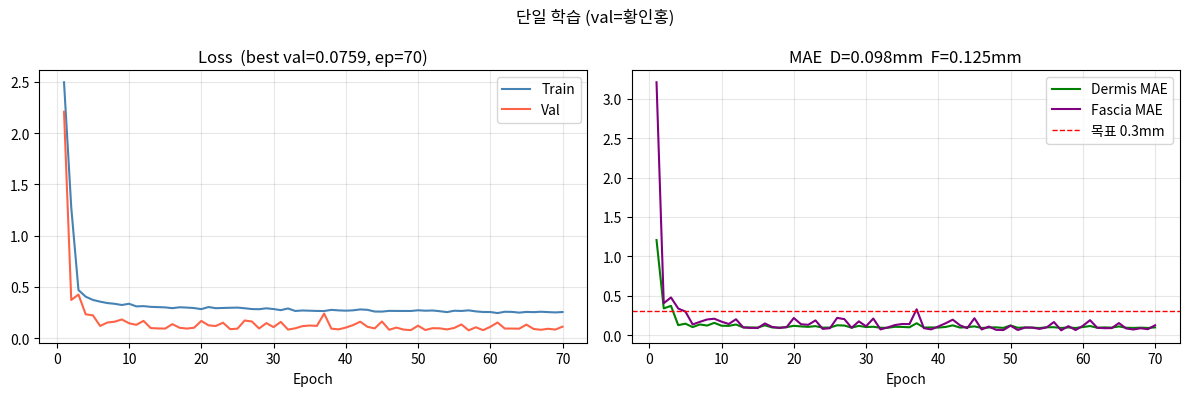


최종 검증 MAE — 진피: 0.0909mm  근막: 0.0609mm
목표 <0.30mm — 진피: ✓ OK  근막: ✓ OK


In [6]:
val_pat    = patients[-1]
train_rows = [r for r in ALL_ROWS if r["patient"] != val_pat]
val_rows   = [r for r in ALL_ROWS if r["patient"] == val_pat]

print(f"Train: {len(train_rows)}개  /  Val: {len(val_rows)}개 (환자: {val_pat})")
print(f"모델 파라미터: {SkinCNN(HP['n_filters'], HP['dropout']).n_params():,}개\n")

single_hp = {**HP, "epochs": HP["epochs"]}
model_single, hist_single = train_model(
    train_rows, val_rows, single_hp,
    live_plot=True,
    title=f"단일 학습 (val={val_pat})"
)

_, mae_d, mae_f, _, _ = eval_epoch(
    model_single,
    DataLoader(UltrasoundDataset(val_rows), batch_size=32),
    nn.L1Loss()
)
print(f"\n최종 검증 MAE — 진피: {mae_d:.4f}mm  근막: {mae_f:.4f}mm")
status_d = '✓ OK' if mae_d < 0.3 else '✗ NG'
status_f = '✓ OK' if mae_f < 0.3 else '✗ NG'
print(f"목표 <0.30mm — 진피: {status_d}  근막: {status_f}")

## 6. LOO-CV (Leave-One-Patient-Out)

In [7]:
def run_loo_cv(all_rows, hp, quick=False):
    patients = sorted({r["patient"] for r in all_rows})
    cv_hp    = {**hp, "epochs": 80 if quick else hp["epochs"]}
    records  = []

    print(f"LOO-CV 시작: {len(patients)}명  (epochs={cv_hp['epochs']})")
    print("-" * 62)

    for i, pat in enumerate(patients):
        tr  = [r for r in all_rows if r["patient"] != pat]
        val = [r for r in all_rows if r["patient"] == pat]

        model, _ = train_model(tr, val, cv_hp,
                               live_plot=False,
                               title=f"[{i+1:2d}/{len(patients)}] {pat}")

        _, mae_d, mae_f, preds, trues = eval_epoch(
            model,
            DataLoader(UltrasoundDataset(val), batch_size=32),
            nn.L1Loss()
        )
        print(f"  [{i+1:2d}/{len(patients)}] {pat:<12s}  "
              f"진피 {mae_d:.3f}mm  근막 {mae_f:.3f}mm  (n={len(val)})")
        records.append({"patient": pat, "n_test": len(val),
                        "mae_dermis": mae_d, "mae_fascia": mae_f,
                        "preds": preds, "trues": trues})

    df = pd.DataFrame(records)
    print("-" * 62)
    print(f"  평균  진피 MAE: {df['mae_dermis'].mean():.3f} ± {df['mae_dermis'].std():.3f} mm")
    print(f"  평균  근막 MAE: {df['mae_fascia'].mean():.3f} ± {df['mae_fascia'].std():.3f} mm")
    return df


# quick=True → 에폭 80으로 줄여 빠르게 실행
# quick=False → HP["epochs"] 전체 실행
CV_DF = run_loo_cv(ALL_ROWS, HP, quick=True)

LOO-CV 시작: 13명  (epochs=80)
--------------------------------------------------------------


[ 1/13] 권영남:   0%|          | 0/80 [00:00<?, ?it/s]

  [ 1/13] 권영남           진피 0.090mm  근막 0.056mm  (n=60)


[ 2/13] 김선일:   0%|          | 0/80 [00:00<?, ?it/s]

  [ 2/13] 김선일           진피 0.088mm  근막 0.052mm  (n=60)


...

  [11/13] 한승현           진피 0.103mm  근막 0.062mm  (n=60)


[12/13] 홍충만:   0%|          | 0/80 [00:00<?, ?it/s]

  [12/13] 홍충만           진피 0.103mm  근막 0.073mm  (n=60)


[13/13] 황인홍:   0%|          | 0/80 [00:00<?, ?it/s]

  [13/13] 황인홍           진피 0.092mm  근막 0.065mm  (n=60)
--------------------------------------------------------------
  평균  진피 MAE: 0.093 ± 0.008 mm
  평균  근막 MAE: 0.063 ± 0.011 mm


## 7. 결과 시각화

RF baseline (pkl): 진피=0.125mm  근막=0.068mm
저장: /home/dmjang/work/ultrasound_analysis/results/cnn_model_cv.png


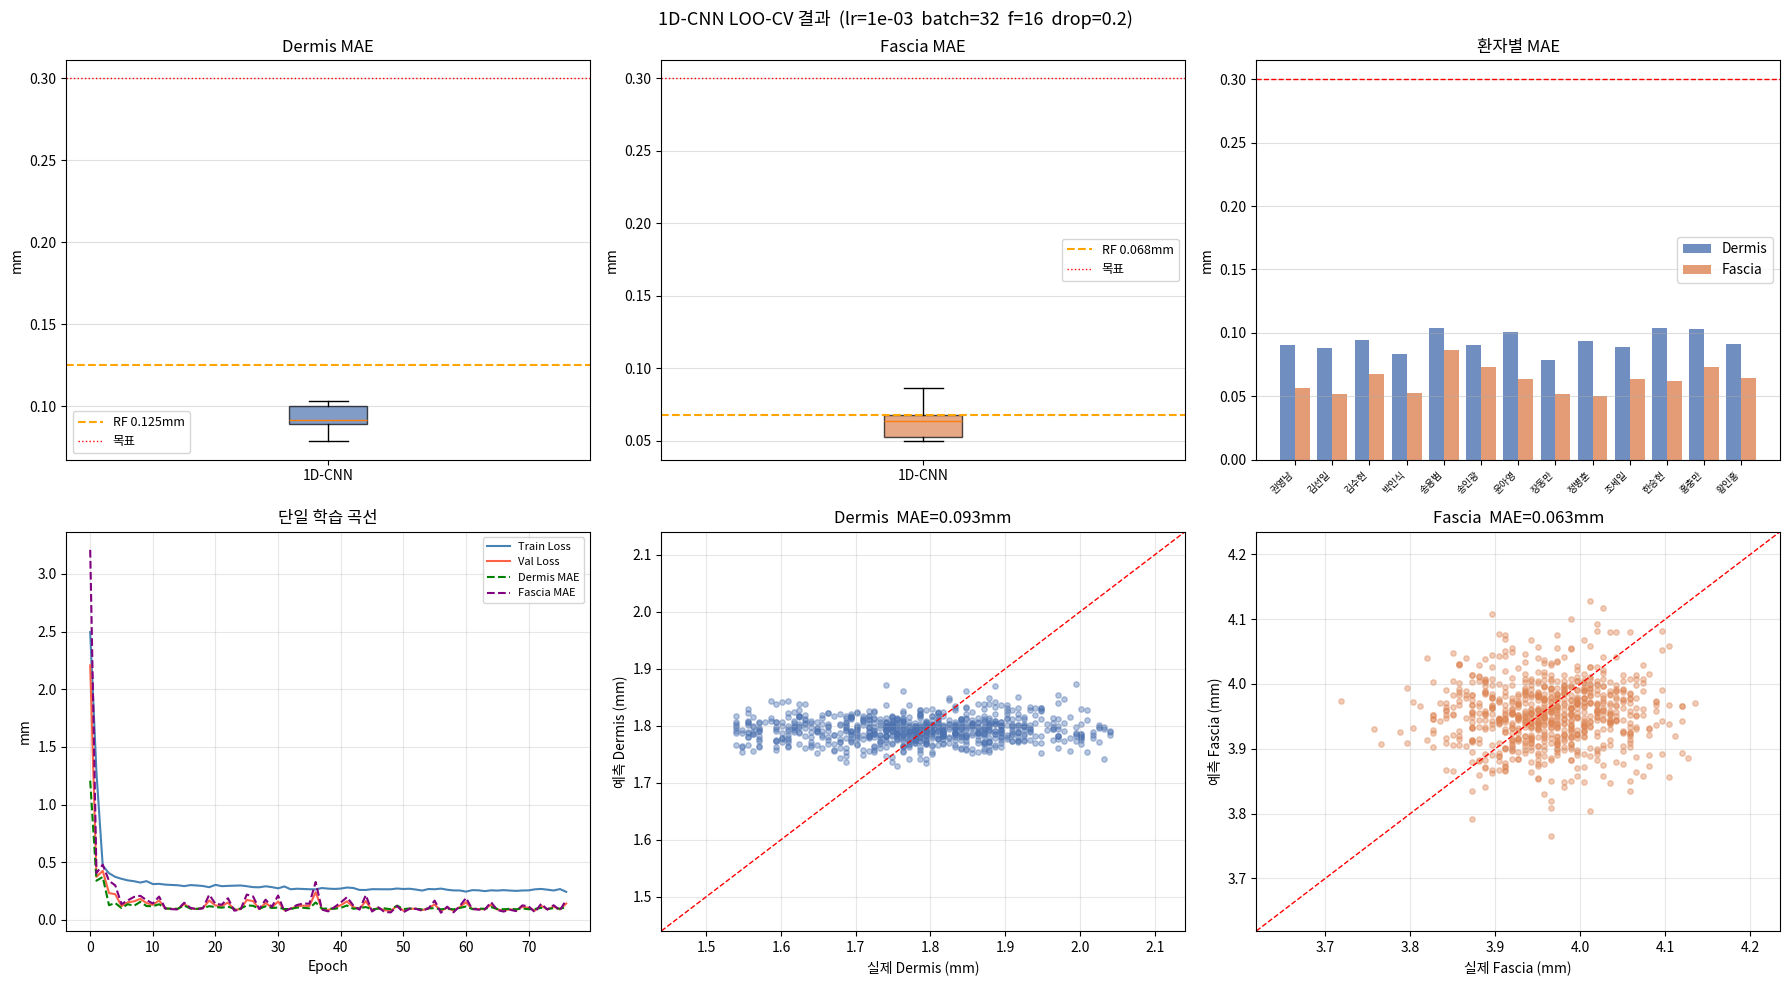

In [8]:
# RF baseline 로드
rf_mae = {"dermis": 0.125, "fascia": 0.068}
rf_pkl = RESULT_DIR / "feature_model.pkl"
if rf_pkl.exists():
    with open(rf_pkl, "rb") as fh:
        rf_data = pickle.load(fh)
    rf_cv = rf_data.get("cv_results", {}).get("Random Forest")
    if rf_cv is not None:
        rf_mae = {"dermis": float(rf_cv["mae_dermis"].mean()),
                  "fascia": float(rf_cv["mae_fascia"].mean())}
        print(f"RF baseline (pkl): 진피={rf_mae['dermis']:.3f}mm  근막={rf_mae['fascia']:.3f}mm")

fig = plt.figure(figsize=(18, 10))
hp_str = f"lr={HP['lr']:.0e}  batch={HP['batch']}  f={HP['n_filters']}  drop={HP['dropout']}"
fig.suptitle(f"1D-CNN LOO-CV 결과  ({hp_str})", fontsize=13)

gs = gridspec.GridSpec(2, 3, figure=fig)

# ① Dermis MAE 분포
ax = fig.add_subplot(gs[0, 0])
ax.boxplot([CV_DF["mae_dermis"].values], tick_labels=["1D-CNN"], patch_artist=True,
           boxprops=dict(facecolor="#4c72b0", alpha=0.7))
ax.axhline(rf_mae["dermis"], color="orange", linestyle="--", linewidth=1.5,
           label=f"RF {rf_mae['dermis']:.3f}mm")
ax.axhline(0.3, color="red", linestyle=":", linewidth=1, label="목표")
ax.set_title("Dermis MAE"); ax.set_ylabel("mm"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

# ② Fascia MAE 분포
ax = fig.add_subplot(gs[0, 1])
ax.boxplot([CV_DF["mae_fascia"].values], tick_labels=["1D-CNN"], patch_artist=True,
           boxprops=dict(facecolor="#dd8452", alpha=0.7))
ax.axhline(rf_mae["fascia"], color="orange", linestyle="--", linewidth=1.5,
           label=f"RF {rf_mae['fascia']:.3f}mm")
ax.axhline(0.3, color="red", linestyle=":", linewidth=1, label="목표")
ax.set_title("Fascia MAE"); ax.set_ylabel("mm"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4)

# ③ 환자별 MAE 막대
ax = fig.add_subplot(gs[0, 2])
x = np.arange(len(CV_DF))
ax.bar(x - 0.2, CV_DF["mae_dermis"], 0.4, label="Dermis", color="#4c72b0", alpha=0.8)
ax.bar(x + 0.2, CV_DF["mae_fascia"], 0.4, label="Fascia",  color="#dd8452", alpha=0.8)
ax.axhline(0.3, color="red", linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(CV_DF["patient"], rotation=45, ha="right", fontsize=7)
ax.set_title("환자별 MAE"); ax.set_ylabel("mm"); ax.legend(); ax.grid(axis="y", alpha=0.4)

# ④ 단일 학습 곡선
ax = fig.add_subplot(gs[1, 0])
ax.plot(hist_single["tr"],    label="Train Loss",   color="steelblue")
ax.plot(hist_single["val"],   label="Val Loss",     color="tomato")
ax.plot(hist_single["mae_d"], label="Dermis MAE",   color="green",  linestyle="--")
ax.plot(hist_single["mae_f"], label="Fascia MAE",   color="purple", linestyle="--")
ax.set_title("단일 학습 곡선"); ax.set_xlabel("Epoch"); ax.set_ylabel("mm")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ⑤⑥ 예측 vs 실제
all_preds = np.concatenate([r["preds"] for r in CV_DF.to_dict("records")])
all_trues = np.concatenate([r["trues"] for r in CV_DF.to_dict("records")])
for col, (ti, label, color) in enumerate(
        zip([0, 1], ["Dermis", "Fascia"], ["#4c72b0", "#dd8452"])):
    ax = fig.add_subplot(gs[1, col + 1])
    ax.scatter(all_trues[:, ti], all_preds[:, ti], alpha=0.4, s=15, color=color)
    lim = [min(all_trues[:, ti].min(), all_preds[:, ti].min()) - 0.1,
           max(all_trues[:, ti].max(), all_preds[:, ti].max()) + 0.1]
    ax.plot(lim, lim, "r--", linewidth=1)
    mae = float(np.mean(np.abs(all_preds[:, ti] - all_trues[:, ti])))
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"실제 {label} (mm)"); ax.set_ylabel(f"예측 {label} (mm)")
    ax.set_title(f"{label}  MAE={mae:.3f}mm")
    ax.grid(alpha=0.3)

fig.tight_layout()
out = RESULT_DIR / "cnn_model_cv.png"
fig.savefig(out, dpi=150)
print(f"저장: {out}")
plt.show()

## 8. 최종 모델 저장

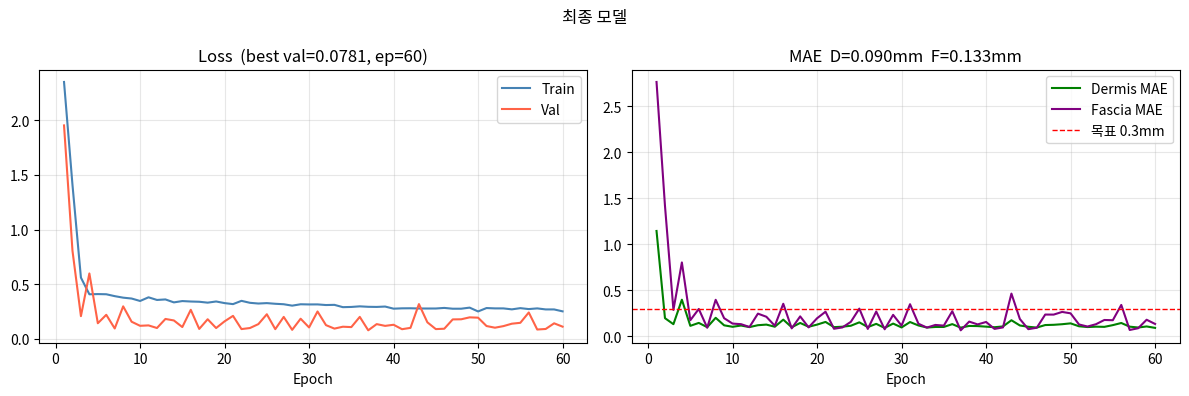


모델 저장: /home/dmjang/work/ultrasound_analysis/results/best_1dcnn.pth

모델                          진피 MAE      근막 MAE
----------------------------------------------
Random Forest (기준)         0.125mm     0.068mm
1D-CNN (LOO-CV)            0.093mm     0.063mm

최적 모델: 1D-CNN


In [9]:
print("최종 모델 학습 중 (전체 데이터)...")
final_hp = {**HP, "epochs": HP["final_ep"], "patience": 30}

final_model, final_hist = train_model(
    ALL_ROWS,
    [r for r in ALL_ROWS if r["patient"] == patients[-1]],  # 검증: 마지막 환자
    final_hp,
    live_plot=True,
    title="최종 모델"
)

model_path = RESULT_DIR / "best_1dcnn.pth"
torch.save({
    "model_state":   final_model.state_dict(),
    "model_class":   "SkinCNN",
    "hyperparams":   HP,
    "input_size":    TRIM_COUNT,
    "cv_mae_dermis": float(CV_DF["mae_dermis"].mean()),
    "cv_mae_fascia": float(CV_DF["mae_fascia"].mean()),
}, model_path)
print(f"\n모델 저장: {model_path}")

# 최종 요약
cnn_d = CV_DF["mae_dermis"].mean()
cnn_f = CV_DF["mae_fascia"].mean()
print(f"\n{'모델':<22s}  {'진피 MAE':>10s}  {'근막 MAE':>10s}")
print("-" * 46)
print(f"{'Random Forest (기준)':<22s}  {rf_mae['dermis']:>8.3f}mm  {rf_mae['fascia']:>8.3f}mm")
print(f"{'1D-CNN (LOO-CV)':<22s}  {cnn_d:>8.3f}mm  {cnn_f:>8.3f}mm")
winner = "1D-CNN" if (cnn_d + cnn_f) < (rf_mae["dermis"] + rf_mae["fascia"]) else "Random Forest"
print(f"\n최적 모델: {winner}")